In [ ]:
import librosa
import librosa.display
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from glob import glob

import os
import sys
sys.path.append(os.path.abspath('..'))

from src.data.augment import *

In [2]:
audio_files = glob('./dataset/raw/RAVDESS/*/*.wav')
print(len(audio_files))
print(audio_files[:5])

1440
['./dataset/raw/RAVDESS\\Actor_01\\03-01-01-01-01-01-01.wav', './dataset/raw/RAVDESS\\Actor_01\\03-01-01-01-01-02-01.wav', './dataset/raw/RAVDESS\\Actor_01\\03-01-01-01-02-01-01.wav', './dataset/raw/RAVDESS\\Actor_01\\03-01-01-01-02-02-01.wav', './dataset/raw/RAVDESS\\Actor_01\\03-01-02-01-01-01-01.wav']


In [3]:
sample = audio_files[0]

y, sr = librosa.load(sample, sr = 22050)
print(sr)
print(y.shape)

c:\Users\dhanr\OneDrive\Documents\ML\Speech_emotion_recognition\audio_env\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


22050
(72838,)


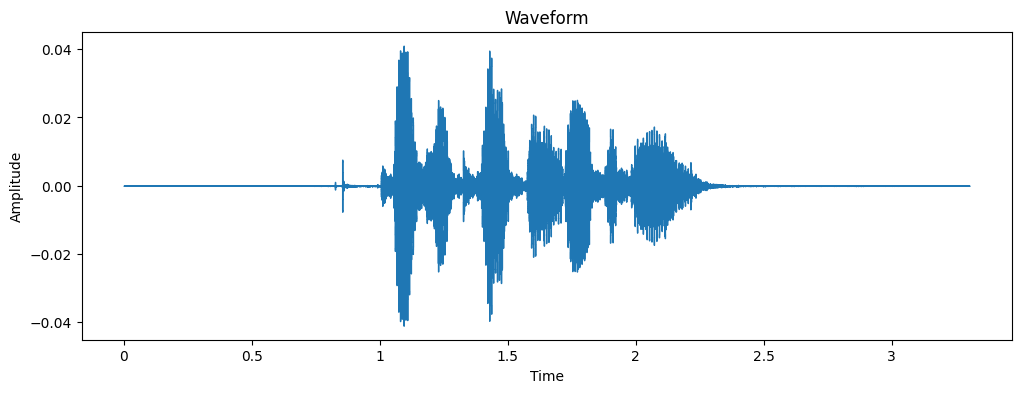

In [4]:
plt.figure(figsize=(12,4))

librosa.display.waveshow(y, sr=sr)

plt.title("Waveform")
plt.xlabel("Time")
plt.ylabel("Amplitude")

plt.show()

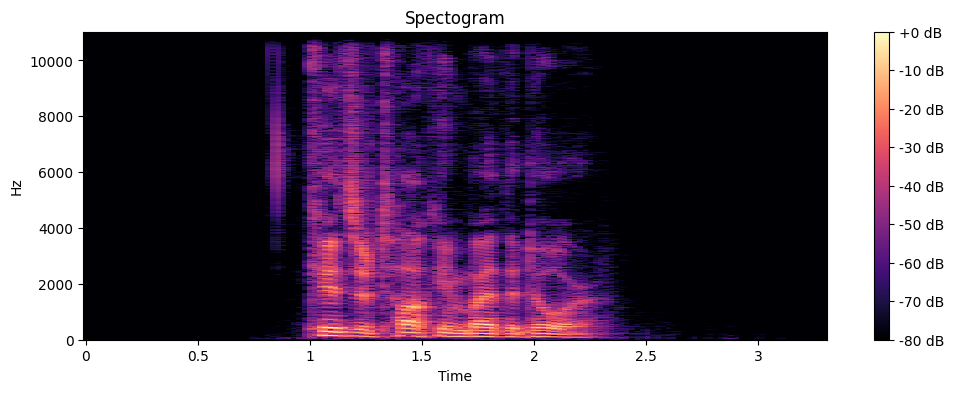

In [5]:
D = librosa.amplitude_to_db(
                            abs(librosa.stft(y)), 
                            ref = np.max)
plt.figure(figsize = (12, 4))
librosa.display.specshow(D,     
                        sr = sr, 
                        x_axis = 'time', 
                        y_axis = 'hz')
plt.colorbar(format = '%+2.0f dB')
plt.title('Spectogram')
plt.show()

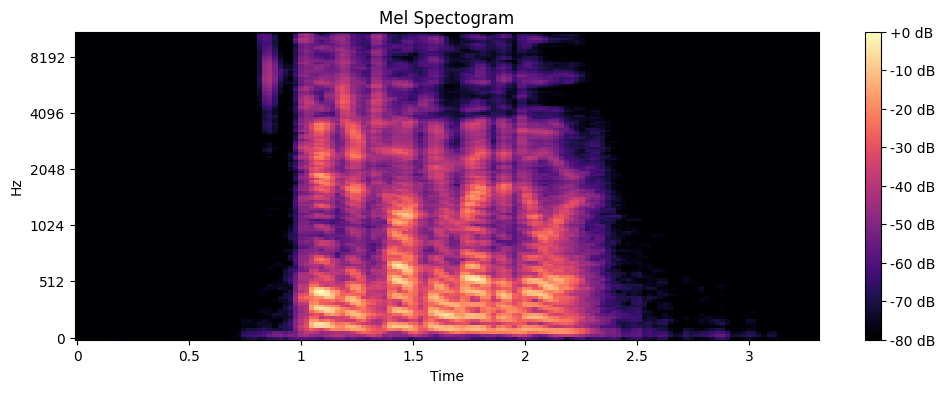

In [6]:
mel = librosa.feature.melspectrogram(
                                    y = y,
                                    sr = sr )
mel_db = librosa.power_to_db(
                            mel,
                            ref = np.max)
plt.figure(figsize = (12, 4))
librosa.display.specshow(
                        mel_db,
                        sr = sr,
                        x_axis = 'time',
                        y_axis = 'mel')
plt.colorbar(format = '%+2.0f dB')
plt.title('Mel Spectogram')
plt.show()                        


In [7]:
stretch_audio = time_stretch(y)
pitch_audio = pitch_shift(y, sr)
noise_audio = add_noise(y)

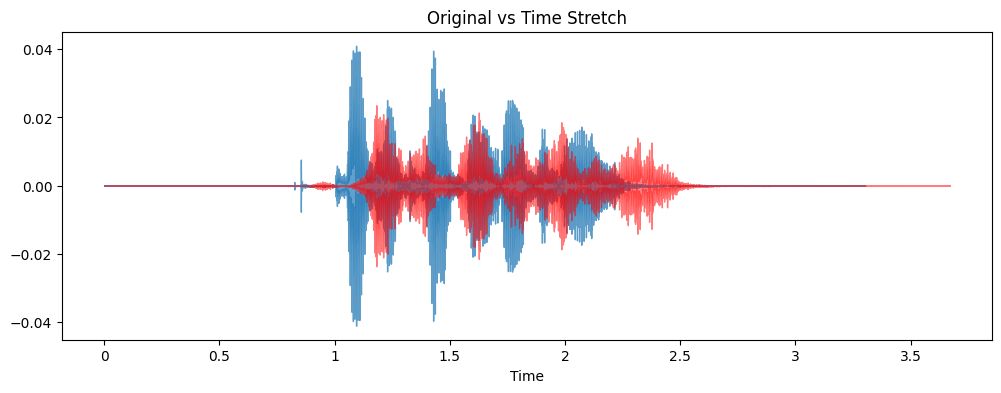

In [8]:
plt.figure(figsize = (12,4))

librosa.display.waveshow(y, 
                         sr = sr, 
                         alpha = 0.7)

librosa.display.waveshow(stretch_audio,
                         sr = sr,
                         color = 'r',
                         alpha = 0.5)

plt.title('Original vs Time Stretch')
plt.show()

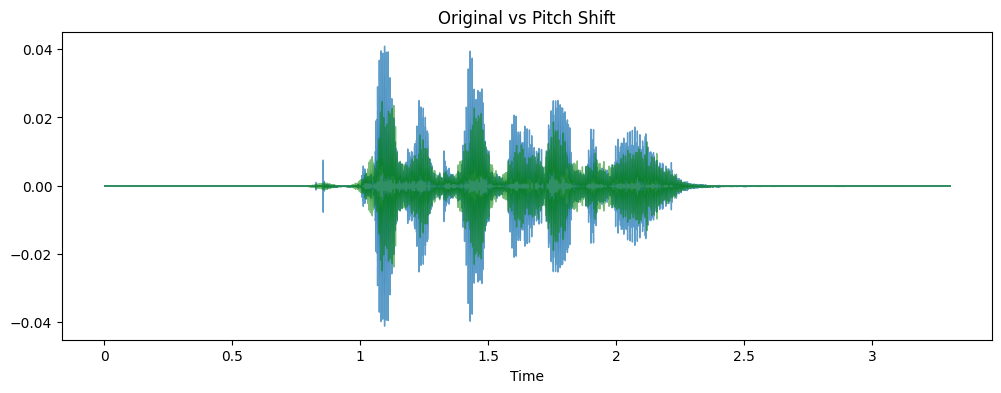

In [9]:
plt.figure(figsize = (12, 4))

librosa.display.waveshow(y,
                         sr = sr,
                         alpha = 0.7)

librosa.display.waveshow(pitch_audio,
                         sr = sr,
                         color = 'g',
                         alpha = 0.5)

plt.title('Original vs Pitch Shift')

plt.show()

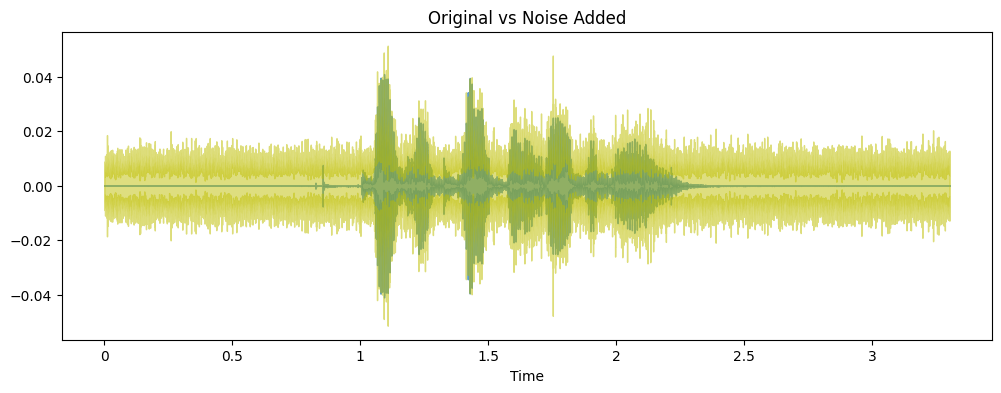

In [10]:
plt.figure(figsize = (12, 4))

librosa.display.waveshow(y,
                         sr = sr,
                         alpha = 0.7)

librosa.display.waveshow(noise_audio,
                         sr = sr,
                         color = 'y',
                         alpha = 0.5)

plt.title('Original vs Noise Added')

plt.show()

In [11]:
CREMAD_MAP = {
    "ANG":"angry",
    "DIS":"disgust",
    "FEA":"fearful",
    "NEU":"neutral",
    "HAP":"happy",
    "SAD":"sad"
}

In [12]:
cremad_files = glob('./dataset/raw/CREMAD/AudioWAV/*.wav')

print(len(cremad_files))
print(cremad_files[:5])

7442
['./dataset/raw/CREMAD/AudioWAV\\1001_DFA_ANG_XX.wav', './dataset/raw/CREMAD/AudioWAV\\1001_DFA_DIS_XX.wav', './dataset/raw/CREMAD/AudioWAV\\1001_DFA_FEA_XX.wav', './dataset/raw/CREMAD/AudioWAV\\1001_DFA_HAP_XX.wav', './dataset/raw/CREMAD/AudioWAV\\1001_DFA_NEU_XX.wav']


In [13]:
emotion_labels = []

for file in cremad_files:
    filename = file.split('\\')[-1]
    emotion_code = filename.split('_')[2]
    emotion = CREMAD_MAP[emotion_code]
    emotion_labels.append(emotion)

print(emotion_labels[:10])    

['angry', 'disgust', 'fearful', 'happy', 'neutral', 'sad', 'angry', 'angry', 'angry', 'disgust']


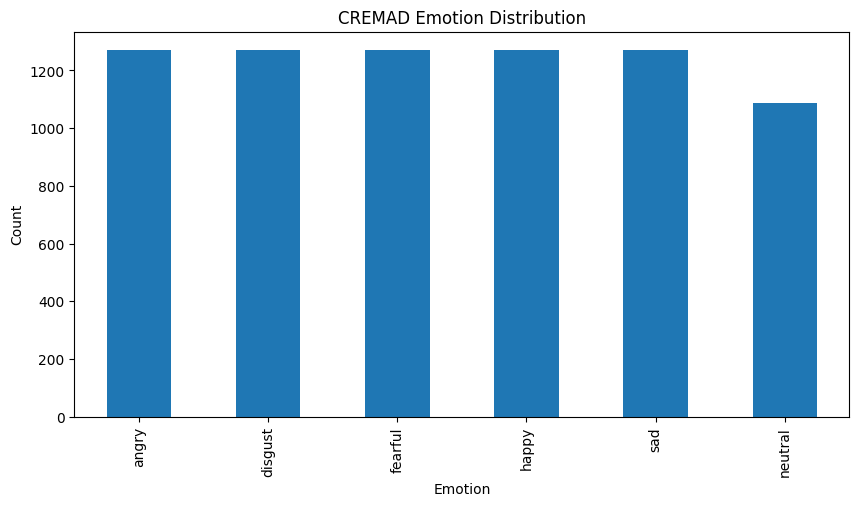

In [14]:
df = pd.DataFrame(emotion_labels,
                  columns = ['emotion'])

df['emotion'].value_counts().plot(kind = 'bar',
                                 figsize = (10, 5))

plt.title("CREMAD Emotion Distribution")
plt.xlabel("Emotion")
plt.ylabel("Count")
plt.show()

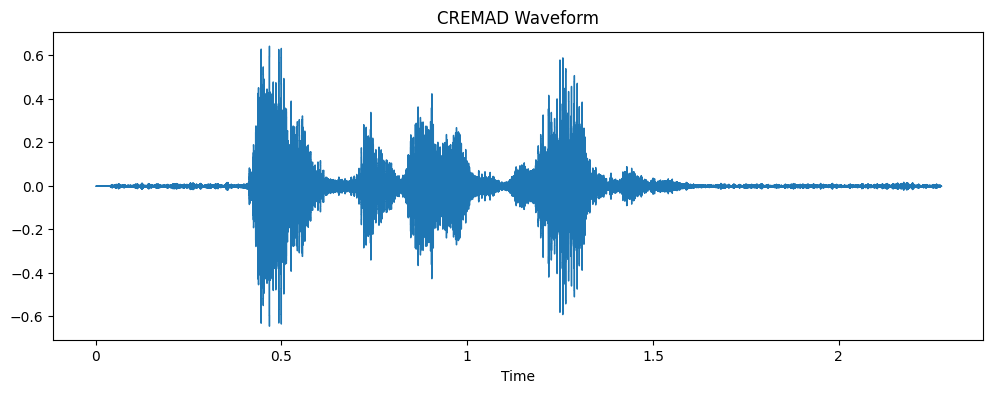

In [15]:
sample = cremad_files[0]

y, sr = librosa.load(sample, sr = 22050)

plt.figure(figsize = (12, 4))
librosa.display.waveshow(y, sr = sr)
plt.title('CREMAD Waveform')
plt.show()